### Exploratory Data Analysis (EDA) - Datasets de Audio

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ─── Rutas Base ────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'data').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent

NEUROVOZ_DIR = PROJECT_ROOT / 'data' / 'original' / 'neurovoz'
PCGITA_DIR = PROJECT_ROOT / 'data' / 'original' / 'pc-gita'

#### 1. Carga de Datos

In [3]:
# 1. Cargar las dos tablas de Neurovoz (Sanos y Enfermos)
df_neurovoz_hc = pd.read_csv(NEUROVOZ_DIR / 'metadata' / 'metadata_hc_vocales.csv')
df_neurovoz_pd = pd.read_csv(NEUROVOZ_DIR / 'metadata' / 'metadata_pd_vocales.csv')

# 2. Diferenciar cada grupo y unirlos en una sola gran tabla
df_neurovoz_hc['Label'] = 'HC'
df_neurovoz_pd['Label'] = 'PD'
df_neurovoz = pd.concat([df_neurovoz_hc, df_neurovoz_pd], ignore_index=True)

# 3. Preparar unas columnas extra para usar más adelante
df_neurovoz['Sex_label'] = df_neurovoz['Sex'].map({1.0: 'Hombre', 0.0: 'Mujer'})
df_neurovoz['Filename'] = df_neurovoz['Audio'].apply(lambda x: str(x).split('/')[-1] if pd.notna(x) else None)
df_neurovoz['Vowel'] = df_neurovoz['Audio'].apply(lambda x: str(x).split('/')[-2] if pd.notna(x) else None)

print(f"NeuroVoz: Tabla cargada correctamente con {len(df_neurovoz)} filas.")

NeuroVoz: Tabla cargada correctamente con 442 filas.


In [4]:
df_neurovoz.head(3)

,ID,Group,Date,Sex,Age,Diagnosis,Vocal tremor,Cephalic tremor,Mandibular tremor,Sialorrhoea,...,Occupation,Fiber/VocalFolds,Observations,Doctor,Audio,Label,Vocal folds analysis,Sex_label,Filename,Vowel
0,34,HC,2016-05-01,1.0,77.0,normal,0,0,0,0,...,retired,Not performed,NaN,NaN,data/audios_reorganizados/Control/E/0034_E2.wav,HC,NaN,Hombre,0034_E2.wav,E
1,34,HC,2016-05-01,1.0,77.0,normal,0,0,0,0,...,retired,Not performed,NaN,NaN,data/audios_reorganizados/Control/A/0034_A1.wav,HC,NaN,Hombre,0034_A1.wav,A
2,34,HC,2016-05-01,1.0,77.0,normal,0,0,0,0,...,retired,Not performed,NaN,NaN,data/audios_reorganizados/Control/E/0034_E3.wav,HC,NaN,Hombre,0034_E3.wav,E


In [5]:
# 1. Cargar la tabla de PC-GITA
df_pcgita = pd.read_excel(PCGITA_DIR / 'metadata' / 'Copia de PCGITA_metadata.xlsx', sheet_name='PD+HC')

# 2. Diferenciar enfermos de sanos analizando su ID (los sanos llevan una 'C' al final de 'AVPEPUDEAC')
df_pcgita['Label'] = df_pcgita['RECODING ORIGINAL NAME'].apply(lambda x: 'HC' if 'AVPEPUDEAC' in str(x) else 'PD')

# 3. Preparar la columna del sexo
df_pcgita['Sex_label'] = df_pcgita['SEX'].map({'M': 'Hombre', 'F': 'Mujer'})

print(f"PC-GITA: Tabla cargada correctamente con {len(df_pcgita)} pacientes.")

PC-GITA: Tabla cargada correctamente con 100 pacientes.


In [6]:
df_pcgita.head(5)

,RECODING ORIGINAL NAME,UPDRS,UPDRS-speech,H/Y,SEX,AGE,time after diagnosis,Label,Sex_label
0,AVPEPUDEA0001,28.0,1.0,2.0,M,64,3.0,PD,Hombre
1,AVPEPUDEA0002,19.0,0.0,1.0,F,72,2.5,PD,Mujer
2,AVPEPUDEA0003,52.0,2.0,3.0,F,75,3.0,PD,Mujer
3,AVPEPUDEA0005,32.0,1.0,2.0,M,65,12.0,PD,Hombre
4,AVPEPUDEA0006,28.0,1.0,2.0,F,66,4.0,PD,Mujer


#### 2. Exploración de los datos

In [7]:
# --- 1. Cálculos de NeuroVoz ---
nv_pat_hc = df_neurovoz[df_neurovoz['Label'] == 'HC']['ID'].nunique()
nv_pat_pd = df_neurovoz[df_neurovoz['Label'] == 'PD']['ID'].nunique()
nv_aud_hc = len(df_neurovoz[df_neurovoz['Label'] == 'HC'])
nv_aud_pd = len(df_neurovoz[df_neurovoz['Label'] == 'PD'])

nv_voc_hc = df_neurovoz[df_neurovoz['Label'] == 'HC']['Vowel'].value_counts().to_dict()
nv_voc_pd = df_neurovoz[df_neurovoz['Label'] == 'PD']['Vowel'].value_counts().to_dict()

# --- 2. Cálculos de PC-GITA ---
pg_pat_hc = len(df_pcgita[df_pcgita['Label'] == 'HC'])
pg_pat_pd = len(df_pcgita[df_pcgita['Label'] == 'PD'])

pg_aud_hc, pg_aud_pd = 0, 0
pg_voc_hc, pg_voc_pd = {}, {}

# Contamos los audios físicos de PC-GITA
for group, label, audio_dic in [('Control', 'HC', pg_voc_hc), ('Patologicas', 'PD', pg_voc_pd)]:
    for vowel in ['A', 'E', 'I', 'O', 'U']:
        path = PCGITA_DIR / 'audios' / group / vowel
        if path.exists():
            count = len([f for f in path.iterdir() if f.suffix == '.wav'])
            audio_dic[vowel] = count
            if label == 'HC': pg_aud_hc += count
            else: pg_aud_pd += count

# --- 3. Impresión del Reporte Completo ---
print("==========================================================")
print("       RESUMEN DE DATASETS       ")
print("==========================================================\n")

print("---------------------- NEUROVOZ --------------------------")
print(f"Pacientes sanos (HC):    {nv_pat_hc}")
print(f"Pacientes enfermos (PD): {nv_pat_pd}")
print(f"Total pacientes:         {nv_pat_hc + nv_pat_pd}\n")
print(f"Audios sanos (HC):       {nv_aud_hc}")
print(f"Audios enfermos (PD):    {nv_aud_pd}")
print(f"Total audios:            {nv_aud_hc + nv_aud_pd}\n")
print(f"Media audios/paciente HC: {nv_aud_hc/nv_pat_hc:.1f}")
print(f"Media audios/paciente PD: {nv_aud_pd/nv_pat_pd:.1f}\n")
print(f"Audios por Vocal (HC): " + ", ".join([f"{k}: {v}" for k, v in nv_voc_hc.items()]))
print(f"Audios por Vocal (PD): " + ", ".join([f"{k}: {v}" for k, v in nv_voc_pd.items()]))
print("\n")

print("---------------------- PC-GITA ---------------------------")
print(f"Pacientes sanos (HC):    {pg_pat_hc}")
print(f"Pacientes enfermos (PD): {pg_pat_pd}")
print(f"Total pacientes:         {pg_pat_hc + pg_pat_pd}\n")
print(f"Audios sanos (HC):       {pg_aud_hc}")
print(f"Audios enfermos (PD):    {pg_aud_pd}")
print(f"Total audios:            {pg_aud_hc + pg_aud_pd}\n")
print(f"Media audios/paciente HC: {pg_aud_hc/pg_pat_hc:.1f}")
print(f"Media audios/paciente PD: {pg_aud_pd/pg_pat_pd:.1f}\n")
print(f"Audios por Vocal (HC): " + ", ".join([f"{k}: {v}" for k, v in pg_voc_hc.items()]))
print(f"Audios por Vocal (PD): " + ", ".join([f"{k}: {v}" for k, v in pg_voc_pd.items()]))
print("\n==========================================================")


       RESUMEN DE DATASETS       

---------------------- NEUROVOZ --------------------------
Pacientes sanos (HC):    55
Pacientes enfermos (PD): 52
Total pacientes:         107

Audios sanos (HC):       190
Audios enfermos (PD):    252
Total audios:            442

Media audios/paciente HC: 3.5
Media audios/paciente PD: 4.8

Audios por Vocal (HC): A: 110, E: 80
Audios por Vocal (PD): A: 133, E: 119


---------------------- PC-GITA ---------------------------
Pacientes sanos (HC):    50
Pacientes enfermos (PD): 50
Total pacientes:         100

Audios sanos (HC):       300
Audios enfermos (PD):    300
Total audios:            600

Media audios/paciente HC: 6.0
Media audios/paciente PD: 6.0

Audios por Vocal (HC): A: 150, E: 150
Audios por Vocal (PD): A: 150, E: 150



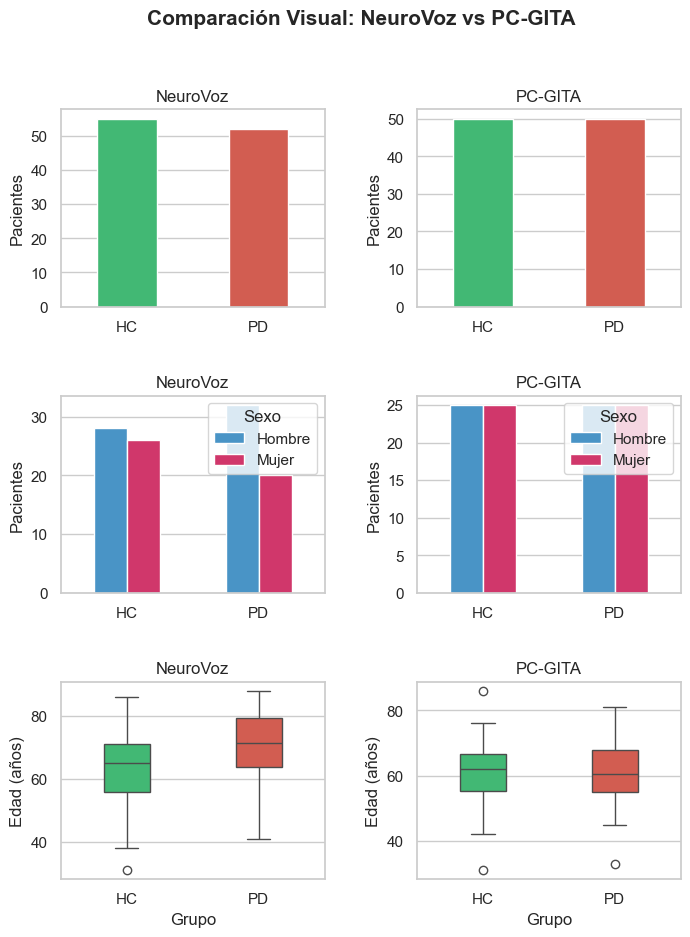

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================
# Preparación de los datos
# ==========================

# Una fila por paciente
df_nv_pacientes = df_neurovoz.drop_duplicates(subset=["ID", "Label"]).copy()

# Convertir edades a numéricas
df_nv_pacientes["Age"] = pd.to_numeric(df_nv_pacientes["Age"], errors="coerce")
df_pcgita["AGE"] = pd.to_numeric(df_pcgita["AGE"], errors="coerce")

# Estilo
sns.set_theme(style="whitegrid")

# Colores
color_grupos = {"HC": "#2ecc71", "PD": "#e74c3c"}
color_sexos = {"Hombre": "#3498db", "Mujer": "#e91e63"}

# ==========================
# Figura
# ==========================

fig, axes = plt.subplots(
    3, 2,
    figsize=(8, 10),                    # Tamaño estándar para notebook
    gridspec_kw={"wspace": 0.35, "hspace": 0.45}
)

fig.suptitle(
    "Comparación Visual: NeuroVoz vs PC-GITA",
    fontsize=15,
    fontweight="bold"
)

# ==========================
# FILA 1 - Número de pacientes
# ==========================

sns.countplot(
    data=df_nv_pacientes,
    x="Label",
    order=["HC", "PD"],
    palette=color_grupos,
    width=0.45,
    ax=axes[0, 0]
)
axes[0, 0].set_title("NeuroVoz")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Pacientes")

sns.countplot(
    data=df_pcgita,
    x="Label",
    order=["HC", "PD"],
    palette=color_grupos,
    width=0.45,
    ax=axes[0, 1]
)
axes[0, 1].set_title("PC-GITA")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Pacientes")

# ==========================
# FILA 2 - Distribución por sexo
# ==========================

sns.countplot(
    data=df_nv_pacientes,
    x="Label",
    hue="Sex_label",
    order=["HC", "PD"],
    palette=color_sexos,
    width=0.50,
    ax=axes[1, 0]
)
axes[1, 0].set_title("NeuroVoz")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Pacientes")
axes[1, 0].legend(title="Sexo")

sns.countplot(
    data=df_pcgita,
    x="Label",
    hue="Sex_label",
    order=["HC", "PD"],
    palette=color_sexos,
    width=0.50,
    ax=axes[1, 1]
)
axes[1, 1].set_title("PC-GITA")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Pacientes")
axes[1, 1].legend(title="Sexo")

# ==========================
# FILA 3 - Distribución de edades
# ==========================

sns.boxplot(
    data=df_nv_pacientes,
    x="Label",
    y="Age",
    order=["HC", "PD"],
    palette=color_grupos,
    width=0.35,
    ax=axes[2, 0]
)
axes[2, 0].set_title("NeuroVoz")
axes[2, 0].set_xlabel("Grupo")
axes[2, 0].set_ylabel("Edad (años)")

sns.boxplot(
    data=df_pcgita,
    x="Label",
    y="AGE",
    order=["HC", "PD"],
    palette=color_grupos,
    width=0.35,
    ax=axes[2, 1]
)
axes[2, 1].set_title("PC-GITA")
axes[2, 1].set_xlabel("Grupo")
axes[2, 1].set_ylabel("Edad (años)")

plt.tight_layout()
plt.show()

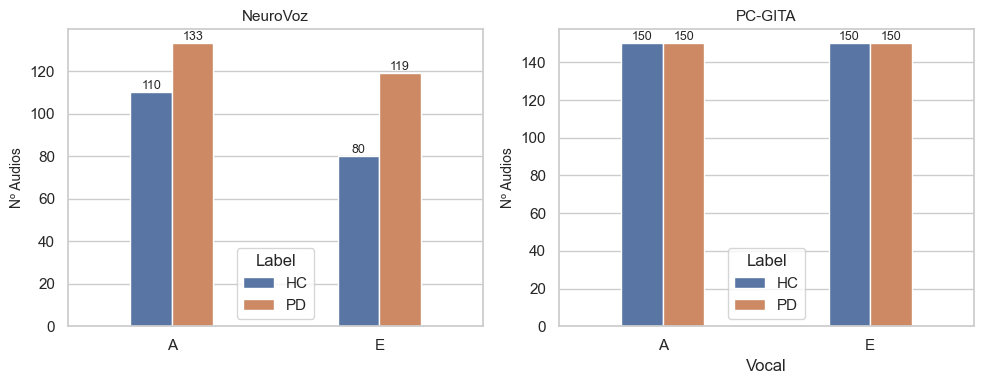

In [9]:
# ============================================================
# Distribución de audios por vocal y grupo
# ============================================================

# 1. Preparar conteo de audios de PC-GITA
vocales_pg = []
for group, label in [('Control', 'HC'), ('Patologicas', 'PD')]:
    for vowel in ['A', 'E']:
        path = PCGITA_DIR / 'audios' / group / vowel
        if path.exists():
            count = len([f for f in path.iterdir() if f.suffix.lower() == '.wav'])
            vocales_pg.append({'Vowel': vowel, 'Label': label, 'Audio_Count': count})

df_pcgita_audios = pd.DataFrame(vocales_pg)

# 2. Figura
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
orden_vocales = ['A', 'E']

# --- IZQUIERDA: NeuroVoz ---
sns.countplot(data=df_neurovoz,x='Vowel',hue='Label',ax=axes[0],order=orden_vocales,width=0.4)

# Añadir valores
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9)

axes[0].set_title('NeuroVoz', fontsize=11)
axes[0].set_ylabel('Nº Audios', fontsize=10)
axes[0].set_xlabel('')

# --- DERECHA: PC-GITA ---
if not df_pcgita_audios.empty:
    sns.barplot(data=df_pcgita_audios,x='Vowel',y='Audio_Count',hue='Label',ax=axes[1],order=orden_vocales,width=0.4)

# Añadir valores
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=9)

axes[1].set_title('PC-GITA', fontsize=11)
axes[1].set_ylabel('Nº Audios', fontsize=10)
axes[1].set_xlabel('Vocal')

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import scipy.stats as stats

# ==========================
# Análisis de edades HC vs PD
# ==========================

# Una fila por paciente
df_nv_pac = df_neurovoz.drop_duplicates(subset=["ID", "Label"]).copy()

# Convertir edad a numérica
df_nv_pac["Age"] = pd.to_numeric(df_nv_pac["Age"], errors="coerce")

# Separar grupos
edades_hc = df_nv_pac.loc[df_nv_pac["Label"] == "HC", "Age"].dropna()
edades_pd = df_nv_pac.loc[df_nv_pac["Label"] == "PD", "Age"].dropna()

# Estadísticas descriptivas
resumen = pd.DataFrame({
    "HC": [
        len(edades_hc),
        edades_hc.mean(),
        edades_hc.median(),
        edades_hc.std(),
        edades_hc.min(),
        edades_hc.max()
    ],
    "PD": [
        len(edades_pd),
        edades_pd.mean(),
        edades_pd.median(),
        edades_pd.std(),
        edades_pd.min(),
        edades_pd.max()
    ]
}, index=[
    "N",
    "Media",
    "Mediana",
    "Desv. estándar",
    "Mínimo",
    "Máximo"
])

print("=== Estadísticas descriptivas de la edad ===")
display(resumen.round(2))

# T-test de Welch
t_stat, p_value = stats.ttest_ind(
    edades_hc,
    edades_pd,
    equal_var=False
)

print("\n=== T-test de Welch ===")
print(f"Estadístico t : {t_stat:.4f}")
print(f"p-value       : {p_value:.6f}")

if p_value < 0.05:
    print("Conclusión: Existe una diferencia significativa entre las edades de HC y PD (p < 0.05).")
else:
    print("Conclusión: No existe una diferencia significativa entre las edades de HC y PD (p ≥ 0.05).")

=== Estadísticas descriptivas de la edad ===


,HC,PD
N,53.00,52.00
Media,64.04,71.46
Mediana,65.00,71.50
Desv. estándar,10.36,10.55
Mínimo,31.00,41.00
Máximo,86.00,88.00



=== T-test de Welch ===
Estadístico t : -3.6375
p-value       : 0.000432
Conclusión: Existe una diferencia significativa entre las edades de HC y PD (p < 0.05).


#### 4 VISUALIZACION DE AUDIOS

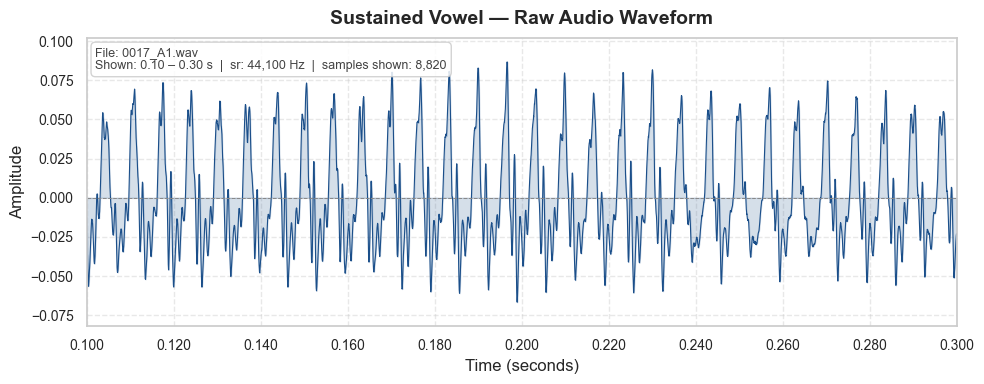

In [ ]:
import random, glob, os, numpy as np, librosa
import matplotlib.pyplot as plt, matplotlib.ticker as ticker, seaborn as sns

# ╔══════════════════════════════════════════╗
# ║  PARÁMETROS                              ║
# ╠══════════════════════════════════════════╣
T_START    = 0.1        # segundo de inicio (float)
T_END      = 0.3        # segundo final     (float)
FIG_W      = 10        # ancho figura en pulgadas
FIG_H      = 4          # alto  figura en pulgadas
# ╚══════════════════════════════════════════╝

# -- Audio aleatorio de NeuroVoz (seed fija = reproducible)
_wavs = glob.glob(str(NEUROVOZ_DIR / 'audios' / '**' / '*.wav'), recursive=True)
random.seed(40)
path = random.choice(_wavs)

y, sr = librosa.load(path, sr=None)
dur   = len(y) / sr
t     = np.linspace(0, dur, len(y), endpoint=False)

# -- Recortar al intervalo deseado
t0 = max(0, T_START)
t1 = min(dur, T_END)
i0, i1 = int(t0 * sr), int(t1 * sr)
t_seg, y_seg = t[i0:i1], y[i0:i1]

# -- Figura
sns.set_theme(style='whitegrid')
C = '#1B4F8A'

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))

ax.fill_between(t_seg, y_seg, alpha=0.18, color=C)
ax.plot(t_seg, y_seg, color=C, linewidth=0.8)
ax.axhline(0, color='#888', linewidth=0.7, linestyle='--')

# Amplitud automática con un 10% de margen
_pad = (y_seg.max() - y_seg.min()) * 0.10 or 0.05
ax.set_ylim(y_seg.min() - _pad, y_seg.max() + _pad)
ax.set_xlim(t0, t1)

ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_ylabel('Amplitude', fontsize=12)
ax.set_title('Sustained Vowel — Raw Audio Waveform', fontsize=14, fontweight='bold', pad=10)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
ax.tick_params(labelsize=10)
ax.grid(True, linestyle='--', alpha=0.45)
ax.margins(x=0)

# Caja de info
info = (f"File: {os.path.basename(path)}\n"
        f"Shown: {t0:.2f} – {t1:.2f} s  |  sr: {sr:,} Hz  |  samples shown: {len(y_seg):,}")
ax.text(0.01, 0.97, info, transform=ax.transAxes, fontsize=9,
        va='top', color='#444',
        bbox=dict(boxstyle='round,pad=0.35', fc='white', alpha=0.85, ec='#CCC'))

plt.tight_layout()
# plt.savefig('raw_waveform_example.pdf', dpi=150, bbox_inches='tight')
plt.show()


#### NORMALIZACION DE LONGITUD Y AMPLITUD

Dataset,Duración MÍNIMA (Capa de Corte),Duración Media,Duración Máxima
NeuroVoz,0.53327 s,3.9343 s,9.8895 s
PC-GITA,0.48891 s,2.9303 s,20.2222 s


PDF guardado: duration_distribution_comparison.pdf


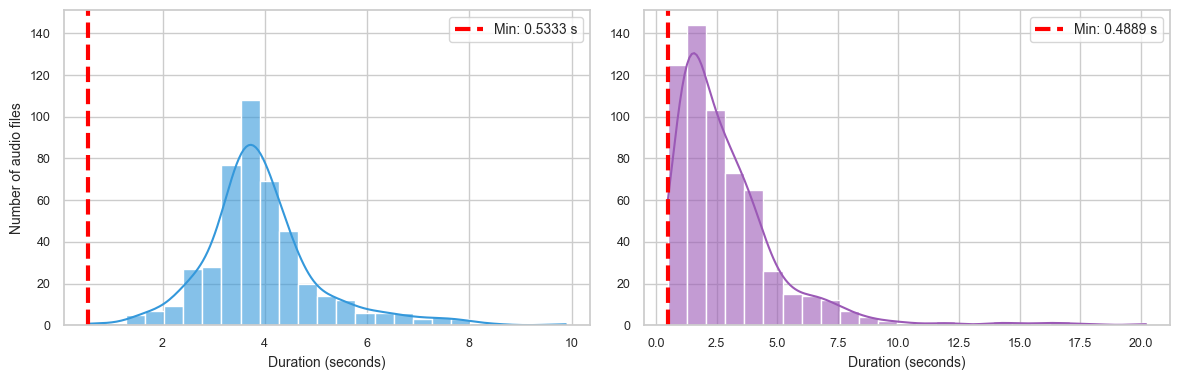

In [12]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')

archivos_pg = list(PCGITA_DIR.rglob('*.wav'))
archivos_nv = list(NEUROVOZ_DIR.rglob('*.wav'))
todos_audios = archivos_pg + archivos_nv

datos_fisicos = []

for i, path in enumerate(todos_audios):
    try:
        y, sr = librosa.load(path, sr=None)
        if len(y) == 0: continue
        
        # 1. Duración matemática
        duracion = len(y) / sr
        
        # 2. Amplitud Media / Energía RMS de toda la señal
        amp_media = np.mean(librosa.feature.rms(y=y))
        
        # 3. Determinar Grupo por las carpetas (Evita cruces con los excel lentos)
        path_str = str(path).lower()
        if 'pc-gita' in path_str:
            dataset = "PC-GITA"
            label = "HC" if "control" in path_str or "pepudeac" in path.name.lower() else "PD"
        else:
            dataset = "NeuroVoz"
            label = "HC" if "control" in path_str else "PD"
            
        datos_fisicos.append({
            'Dataset': dataset,
            'Label': label,
            'Duración (s)': duracion,
            'Amplitud Media': amp_media
        })
        
        if (i+1) % 200 == 0: print(f"")
    except:
        pass

df_fisico = pd.DataFrame(datos_fisicos)

# Cortamos la tabla en dos partes
df_nv = df_fisico[df_fisico['Dataset'] == 'NeuroVoz']
df_pg = df_fisico[df_fisico['Dataset'] == 'PC-GITA']

min_dur_nv = df_nv['Duración (s)'].min()
min_dur_pg = df_pg['Duración (s)'].min()

# ============================================================
# 1. TABLA RESUMEN DE VALORES EXACTOS (NUEVO)
# ============================================================
stats_html = f"""
<div style="display: flex; justify-content: center; margin-bottom: 20px;">
    <table style="border-collapse: collapse; width: 80%; font-size: 15px; text-align: center; border: 1px solid #ddd; background-color: #fdfdfd; box-shadow: 2px 2px 8px rgba(0,0,0,0.05);">
        <tr style="background-color: #f2f2f2;">
            <th style="padding: 12px; border: 1px solid #ddd;">Dataset</th>
            <th style="padding: 12px; border: 1px solid #ddd;">Duración MÍNIMA (Capa de Corte)</th>
            <th style="padding: 12px; border: 1px solid #ddd;">Duración Media</th>
            <th style="padding: 12px; border: 1px solid #ddd;">Duración Máxima</th>
        </tr>
        <tr>
            <td style="padding: 12px; border: 1px solid #ddd; font-weight: bold; color: #2980b9;">NeuroVoz</td>
            <td style="padding: 12px; border: 1px solid #ddd; color: #e74c3c; font-weight: bold;">{min_dur_nv:.5f} s</td>
            <td style="padding: 12px; border: 1px solid #ddd;">{df_nv['Duración (s)'].mean():.4f} s</td>
            <td style="padding: 12px; border: 1px solid #ddd;">{df_nv['Duración (s)'].max():.4f} s</td>
        </tr>
        <tr>
            <td style="padding: 12px; border: 1px solid #ddd; font-weight: bold; color: #8e44ad;">PC-GITA</td>
            <td style="padding: 12px; border: 1px solid #ddd; color: #e74c3c; font-weight: bold;">{min_dur_pg:.5f} s</td>
            <td style="padding: 12px; border: 1px solid #ddd;">{df_pg['Duración (s)'].mean():.4f} s</td>
            <td style="padding: 12px; border: 1px solid #ddd;">{df_pg['Duración (s)'].max():.4f} s</td>
        </tr>
    </table>
</div>
"""
display(HTML(stats_html))


# ============================================================
# 2. PINTADO DEL DIAGNÓSTICO GRÁFICO - DURACIONES SOLO
# ============================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- IZQUIERDA: NeuroVoz DURACIONES ---
sns.histplot(data=df_nv, x='Duración (s)', ax=axes[0], color='#3498db', kde=True, bins=25, alpha=0.6)
axes[0].axvline(min_dur_nv, color='red', linestyle='--', linewidth=3, label=f'Min: {min_dur_nv:.4f} s')
axes[0].set_ylabel('Number of audio files', fontsize=10)
axes[0].set_xlabel('Duration (seconds)', fontsize=10)
axes[0].tick_params(labelsize=9)
axes[0].legend(loc='upper right', fontsize=10, frameon=True)

# --- DERECHA: PC-GITA DURACIONES ---
sns.histplot(data=df_pg, x='Duración (s)', ax=axes[1], color='#9b59b6', kde=True, bins=25, alpha=0.6)
axes[1].axvline(min_dur_pg, color='red', linestyle='--', linewidth=3, label=f'Min: {min_dur_pg:.4f} s')
axes[1].set_ylabel('', fontsize=10)
axes[1].set_xlabel('Duration (seconds)', fontsize=10)
axes[1].tick_params(labelsize=9)
axes[1].legend(loc='upper right', fontsize=10, frameon=True)

# Igualar escalas Y
ylim_top = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(0, ylim_top)
axes[1].set_ylim(0, ylim_top)

plt.tight_layout(pad=1.2)
fig.savefig('duration_distribution_comparison.pdf', format='pdf', bbox_inches='tight')
print('PDF guardado: duration_distribution_comparison.pdf')
plt.show()

paleta = {'HC': '#2ecc71', 'PD': '#e74c3c'}


,Dataset,N HC,N PD,HC media,PD media,HC mediana,PD mediana,t-stat,p-value,p < 0.05
0,NeuroVoz,199,255,0.034671,0.044391,0.022034,0.021177,-1.7330,0.0839,No
1,PC-GITA,300,300,0.030250,0.025761,0.013597,0.021393,1.4686,0.1428,No


PDF guardado: amplitude_neurovoz.pdf


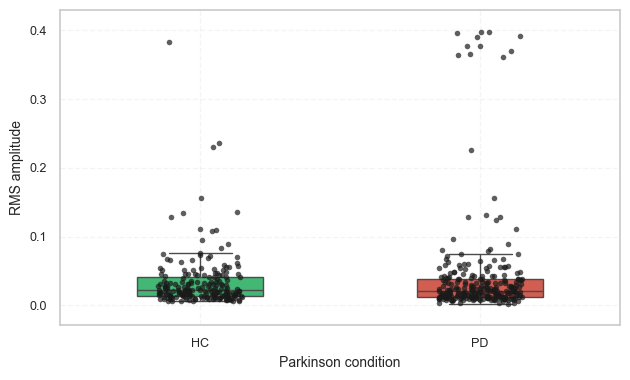

PDF guardado: amplitude_pc_gita.pdf


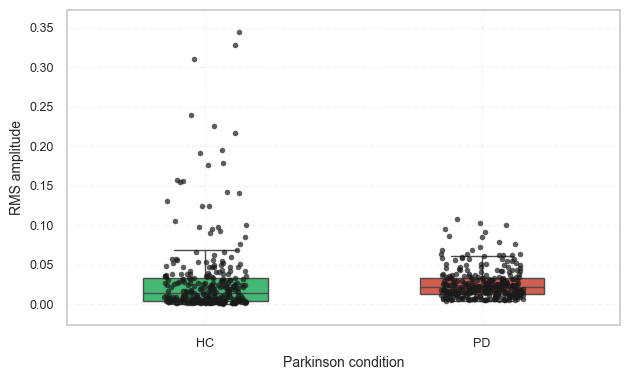

In [13]:
import scipy.stats as stats

# === ANÁLISIS DE AMPLITUD POR DATASET ===

summary_rows = []
for dataset, df_set in [('NeuroVoz', df_nv), ('PC-GITA', df_pg)]:
    hc_vals = df_set.loc[df_set['Label'] == 'HC', 'Amplitud Media']
    pd_vals = df_set.loc[df_set['Label'] == 'PD', 'Amplitud Media']
    n_hc, n_pd = len(hc_vals), len(pd_vals)

    if n_hc > 0 and n_pd > 0:
        t_stat, p_t = stats.ttest_ind(hc_vals, pd_vals, equal_var=False)
        significant = 'Sí' if p_t < 0.05 else 'No'
        mean_hc, mean_pd = hc_vals.mean(), pd_vals.mean()
        med_hc, med_pd = hc_vals.median(), pd_vals.median()
    else:
        t_stat, p_t = np.nan, np.nan
        significant = 'N/A'
        mean_hc = mean_pd = med_hc = med_pd = np.nan

    summary_rows.append({
        'Dataset': dataset,
        'N HC': n_hc,
        'N PD': n_pd,
        'HC media': mean_hc,
        'PD media': mean_pd,
        'HC mediana': med_hc,
        'PD mediana': med_pd,
        't-stat': t_stat,
        'p-value': p_t,
        'p < 0.05': significant
    })

summary_table = pd.DataFrame(summary_rows)
summary_table = summary_table[['Dataset', 'N HC', 'N PD', 'HC media', 'PD media', 'HC mediana', 'PD mediana', 't-stat', 'p-value', 'p < 0.05']]

display(HTML('<h3>Resumen estadístico de amplitud por dataset</h3>'))
display(summary_table.style.format({
    'HC media': '{:.6f}',
    'PD media': '{:.6f}',
    'HC mediana': '{:.6f}',
    'PD mediana': '{:.6f}',
    't-stat': '{:.4f}',
    'p-value': '{:.4f}'
}))
display(HTML('<p><b>Criterio t-test:</b> p < 0.05 indica diferencia estadísticamente significativa entre HC y PD.</p>'))

# Configura aquí el tamaño de las figuras para las gráficas de amplitud
FIG_SIZE_WIDTH = 6.5
FIG_SIZE_HEIGHT = 4

for dataset, df_set in [('NeuroVoz', df_nv), ('PC-GITA', df_pg)]:
    df_plot = df_set.copy()
    df_plot['Label'] = pd.Categorical(df_plot['Label'], categories=['HC', 'PD'])

    fig, ax = plt.subplots(figsize=(FIG_SIZE_WIDTH, FIG_SIZE_HEIGHT))
    sns.boxplot(data=df_plot, x='Label', y='Amplitud Media', ax=ax, palette=paleta, order=['HC', 'PD'], width=0.45, showfliers=False)
    sns.stripplot(data=df_plot, x='Label', y='Amplitud Media', ax=ax, color='k', size=4, jitter=0.15, alpha=0.7, order=['HC', 'PD'])

    ax.set_ylabel('RMS amplitude', fontsize=10)
    ax.set_xlabel('Parkinson condition', fontsize=10)
    ax.tick_params(labelsize=9)
    ax.grid(alpha=0.2, linestyle='--')

    values = df_plot['Amplitud Media'].dropna()
    if len(values) > 0:
        vmin, vmax = values.min(), values.max()
        padding = max((vmax - vmin) * 0.08, 0.00001)
        ax.set_ylim(vmin - padding, vmax + padding)

    plt.tight_layout(pad=1.2)
    filename = f'amplitude_{dataset.lower().replace("-", "_")}.pdf'
    fig.savefig(filename, format='pdf', bbox_inches='tight')
    print(f'PDF guardado: {filename}')
    plt.show()
